In [15]:
import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Tuple, Optional, List
from torch.func import vmap, jacrev
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [16]:
class Sampleable(ABC):
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        pass

class ConditionalProbabilityPath(nn.Module, ABC):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        num_samples = t.shape[0]
        z, _ = self.sample_conditioning_variable(num_samples)
        x = self.sample_conditional_path(z, t)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pass

    @abstractmethod  
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        pass



In [17]:
# 更改MNIST （时间序列建模）
class SimpleTrajectoryDataset(Sampleable):
    def __init__(self, seq_len=50, dim=2, num_classes=3):
        self.seq_len = seq_len
        self.dim = dim
        self.num_classes = num_classes
    
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        labels = torch.randint(0, self.num_classes, (num_samples,))
        trajectories = []
        
        for label in labels:
            label_val = label.item()
            # 时间序列：从t=0到t=seq_len-1
            t = np.linspace(0, 2*np.pi, self.seq_len)
            
            if label_val == 0:  # 圆形时间序列
                x = np.cos(t) * 0.5
                y = np.sin(t) * 0.5
                traj = np.stack([x, y], axis=-1)
            elif label_val == 1:  # 直线时间序列
                x = np.linspace(-0.5, 0.5, self.seq_len)
                y = x * 0.5
                traj = np.stack([x, y], axis=-1)
            else:  # 椭圆时间序列
                x = np.cos(t) * 0.7
                y = np.sin(t) * 0.3
                traj = np.stack([x, y], axis=-1)
            
            trajectories.append(traj)
        
        trajectories = torch.tensor(np.array(trajectories), dtype=torch.float32).to(device)
        return trajectories, labels.to(device)

class TrajectoryNoise(Sampleable):
    def __init__(self, seq_len=50, dim=2):
        self.seq_len = seq_len
        self.dim = dim
    
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        # 生成随机噪声轨迹
        trajectories = torch.randn(num_samples, self.seq_len, self.dim).to(device)
        return trajectories, None

In [18]:
# class LinearAlpha(nn.Module):
#     def forward(self, t):
#         return t.squeeze()

# class LinearBeta(nn.Module):
#     def forward(self, t):
#         return 1 - t.squeeze()

In [19]:
#alpha beta scheduler

class Alpha(ABC):
    def __init__(self):
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,1,1)), torch.zeros(1,1,1)
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(torch.ones(1,1,1)), torch.ones(1,1,1)
        )
        
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - alpha_t (num_samples, 1, 1)
        """ 
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1, 1)
        """ 
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1, 1, 1)
    
class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1,1,1)), torch.ones(1,1,1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1,1,1)), torch.zeros(1,1,1)
        )
        
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - beta_t (num_samples, 1, 1)
        """ 
        pass 

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - d/dt beta_t (num_samples, 1, 1)
        """ 
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1, 1, 1)

class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """
    
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - alpha_t (num_samples, 1, 1)
        """ 
        return t
    
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1, 1)
        """ 
        return torch.ones_like(t)
        
class LinearBeta(Beta):
    """
    Implements beta_t = 1-t
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1)
        Returns:
            - beta_t (num_samples, 1)
        """ 
        return 1-t
        
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1, 1)
        """ 
        return - torch.ones_like(t)

In [20]:
# Conv1d时间序列U-Net 
#t（bs，1） ->  (bs, dim)
class FourierEncoder(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - t: (bs, 1, 1) 扩散时间步
        Returns:
        - embeddings: (bs, dim) 时间编码
        """
        t = t.view(-1, 1)  # (bs, 1)
        freqs = t * self.weights * 2 * math.pi  # (bs, half_dim)
        sin_embed = torch.sin(freqs)  # (bs, half_dim)
        cos_embed = torch.cos(freqs)  # (bs, half_dim)
        # cat：将sin和cos编码拼接成完整的时间表示
        return torch.cat([sin_embed, cos_embed], dim=-1) * math.sqrt(2)  # (bs, dim)

#hidden layer设置，为了非线性映射
#便成con1d
class SimpleTrajectoryUNet(nn.Module):
    def __init__(self, 
                 seq_len: int = 50,
                 input_dim: int = 2,  # 轨迹坐标维度(x,y)
                 hidden_dims: List[int] = [64, 128],
                 t_embed_dim: int = 64,
                 y_embed_dim: int = 32,
                 num_classes: int = 3): 
        super().__init__()
        
        # 输入投影：(seq_len, input_dim) -> (seq_len, hidden_dim)
        self.input_proj = nn.Linear(input_dim, hidden_dims[0])
        
        # 扩散时间步编码器
        self.time_embedder = FourierEncoder(t_embed_dim)
        
        # 轨迹类别编码器
        self.y_embedder = nn.Embedding(num_classes, y_embed_dim)
        
        # 将时间和类别信息投影到隐藏维度
        self.time_proj = nn.Linear(t_embed_dim, hidden_dims[0])
        self.y_proj = nn.Linear(y_embed_dim, hidden_dims[0])

        # 编码器：用Conv1d处理时间序列特征
        self.encoder_convs = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()
        
        for i in range(len(hidden_dims) - 1):
            # Conv1d卷积块：在时间维度上提取局部模式
            self.encoder_convs.append(
                nn.Sequential(
                    nn.Conv1d(hidden_dims[i], hidden_dims[i], kernel_size=3, padding=1),
                    nn.SiLU(),
                    nn.Conv1d(hidden_dims[i], hidden_dims[i], kernel_size=3, padding=1),
                    nn.SiLU()
                )
            )
            # 下采样：减少时间分辨率
            self.downsample_layers.append(
                nn.Conv1d(hidden_dims[i], hidden_dims[i+1], kernel_size=3, stride=2, padding=1)
            )
        
        # 中间层：最深层的特征处理
        self.mid_conv = nn.Sequential(
            nn.Conv1d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv1d(hidden_dims[-1], hidden_dims[-1], kernel_size=3, padding=1),
            nn.SiLU()
        )
        
        # 解码器：恢复时间分辨率
        self.upsample_layers = nn.ModuleList()
        self.decoder_convs = nn.ModuleList()
        
        for i in range(len(hidden_dims) - 1, 0, -1):
            # 上采样：增加时间分辨率
            self.upsample_layers.append(
                nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
                    nn.Conv1d(hidden_dims[i], hidden_dims[i-1], kernel_size=3, padding=1)
                )
            )
            # Conv1d解码块
            self.decoder_convs.append(
                nn.Sequential(
                    nn.Conv1d(hidden_dims[i-1], hidden_dims[i-1], kernel_size=3, padding=1),
                    nn.SiLU(),
                    nn.Conv1d(hidden_dims[i-1], hidden_dims[i-1], kernel_size=3, padding=1),
                    nn.SiLU()
                )
            )
        
        # 输出投影：(seq_len, hidden_dim) -> (seq_len, input_dim)
        self.output_proj = nn.Linear(hidden_dims[0], input_dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, seq_len, input_dim) 时间序列轨迹
        - t: (bs, 1, 1) 扩散时间步
        - y: (bs,) 轨迹类别标签
        Returns:
        - output: (bs, seq_len, input_dim) 预测的轨迹
        """
        bs, seq_len, input_dim = x.shape

        # 处理扩散时间步维度
        if t.dim() == 4:  # (bs, 1, 1, 1) -> (bs, 1, 1)
            t = t.squeeze(-1)
        
        # 编码扩散时间步和轨迹类别
        t_embed = self.time_embedder(t)  # (bs, t_embed_dim)
        y_embed = self.y_embedder(y)     # (bs, y_embed_dim)
        
        # 投影到隐藏维度
        t_proj = self.time_proj(t_embed).unsqueeze(-1)  # (bs, hidden_dim, 1)
        y_proj = self.y_proj(y_embed).unsqueeze(-1)     # (bs, hidden_dim, 1)
        
        # 输入投影
        x = self.input_proj(x)  # (bs, seq_len, hidden_dim)
        x = x.transpose(1, 2)   # (bs, hidden_dim, seq_len) 为Conv1d做准备
        
        # 添加时间和类别信息到所有时间步
        x = x + t_proj + y_proj
        
        # U-Net编码器
        skip_connections = []
        for conv, downsample in zip(self.encoder_convs, self.downsample_layers):
            x = conv(x)  # 在时间维度上卷积
            skip_connections.append(x)  # 保存跳跃连接
            x = downsample(x)  # 时间下采样

        # 中间层处理
        x = self.mid_conv(x)

        # U-Net解码器
        for upsample, conv in zip(self.upsample_layers, self.decoder_convs):
            x = upsample(x)  # 时间上采样
            skip = skip_connections.pop()  # 取出跳跃连接
            x = x + skip  # 残差连接
            x = conv(x)  # 在时间维度上卷积

        # 输出处理
        x = x.transpose(1, 2)  # (bs, seq_len, hidden_dim)
        x = self.output_proj(x)  # (bs, seq_len, input_dim)
        
        return x


class TrajectoryConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_simple: Sampleable, p_data: Sampleable, 
                 alpha: Alpha, beta: Beta):
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta
    
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: (num_samples, seq_len, dim)
            - y: (num_samples)
        """
        z, y = self.p_data.sample(num_samples)  # z: (num_samples, seq_len, dim), y: (num_samples,)
        return z, y
    
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning trajectory (num_samples, seq_len, dim)
            - t: time (num_samples, )
        Returns:
            - x: samples from p_t(x|z), (num_samples, seq_len, dim)
        
        """
        num_samples = z.shape[0]
        
        
        noise, _ = self.p_simple.sample(num_samples)  # (num_samples, seq_len, dim)
        
       
        alpha_t = self.alpha(t).view(-1, 1, 1)  # (num_samples, 1, 1)
        beta_t = self.beta(t).view(-1, 1, 1)    # (num_samples, 1, 1)
        
       
        x_t = alpha_t * z + beta_t * noise
        
        return x_t

展示真实轨迹时间序列...


C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-

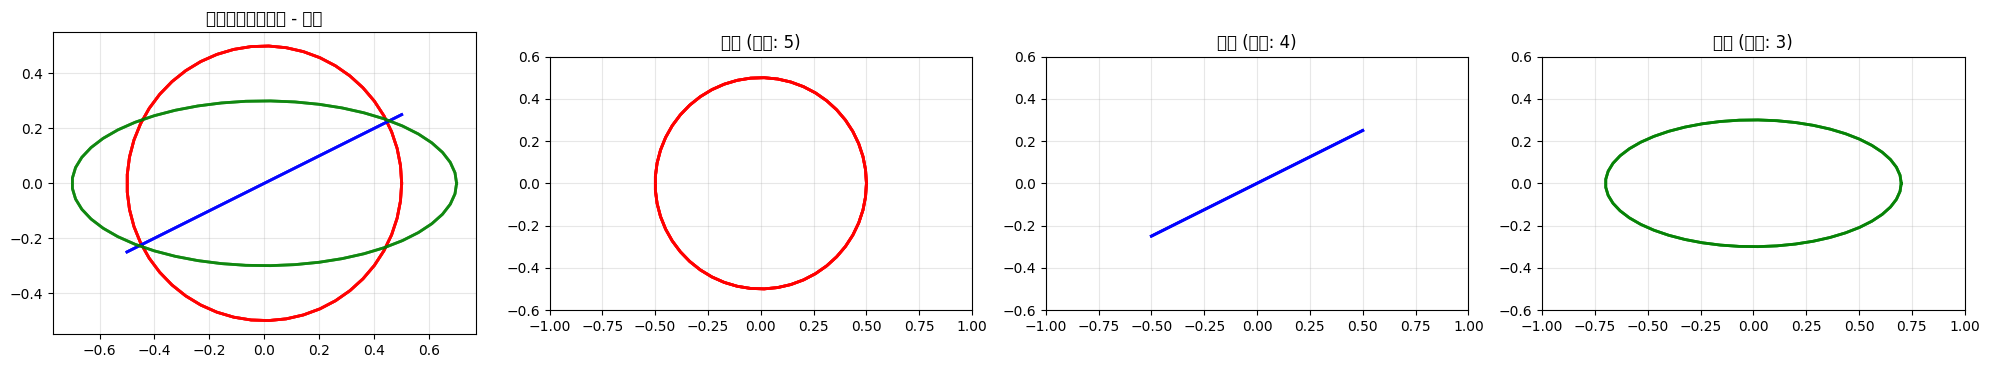

模型参数数量: 204,034


训练进度: 100%|██████████| 1000/1000 [00:05<00:00, 197.78it/s, Loss=0.014869]


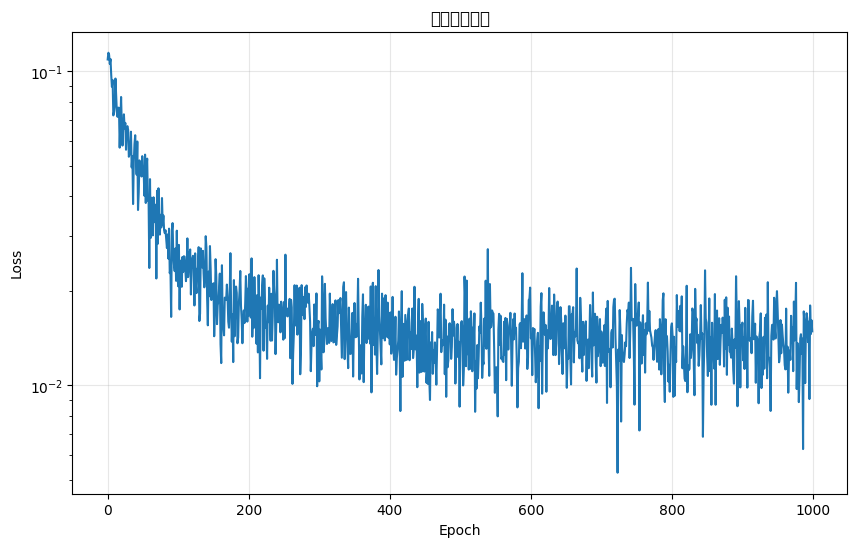

C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


生成新的轨迹时间序列...


C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:32: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


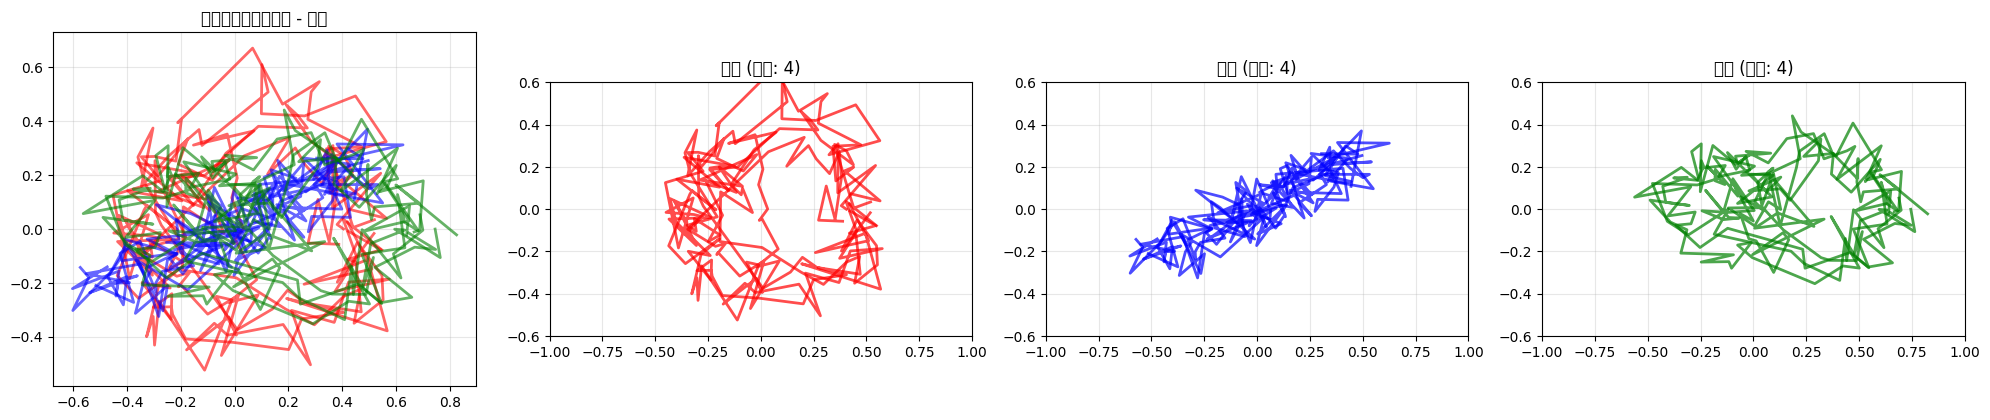

C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:177: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:177: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:177: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:177: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:177: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_8972\191928217.py:177: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEO

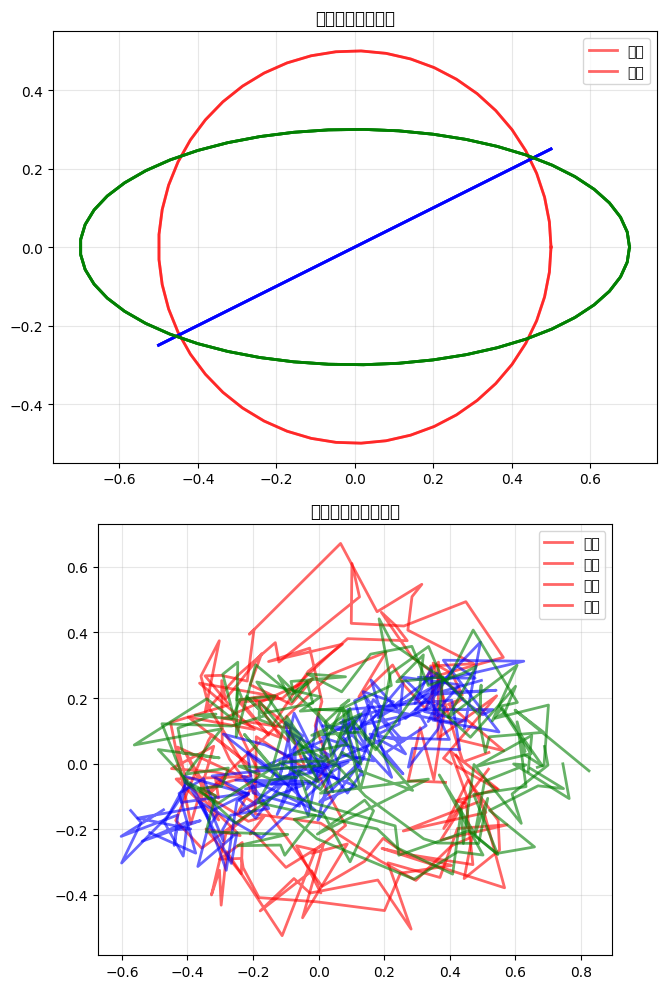

In [21]:
def plot_trajectories(trajectories, labels, title="Trajectories"):
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    class_names = ['圆形', '直线', '椭圆']
    colors = ['red', 'blue', 'green']
    
    # 总览
    for class_idx in range(3):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_trajs = trajectories[mask]
            for traj in class_trajs:
                axes[0].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2)
    axes[0].set_title(f'{title} - 总览')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    
    # 分类别显示
    for class_idx in range(3):
        mask = labels == class_idx
        if mask.sum() > 0:
            class_trajs = trajectories[mask]
            for traj in class_trajs:
                axes[class_idx + 1].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.7, linewidth=2)
        axes[class_idx + 1].set_title(f'{class_names[class_idx]} (数量: {mask.sum()})')
        axes[class_idx + 1].set_aspect('equal')
        axes[class_idx + 1].grid(True, alpha=0.3)
        axes[class_idx + 1].set_xlim(-1, 1)
        axes[class_idx + 1].set_ylim(-0.6, 0.6)
    
    plt.tight_layout()
    plt.show()


def train_diffusion_model():
  
    
    # 创建数据集
    trajectory_data = SimpleTrajectoryDataset(seq_len=50, num_classes=3)
    trajectory_noise = TrajectoryNoise(seq_len=50, dim=2)
    
    # 创建扩散系数
    alpha = LinearAlpha()
    beta = LinearBeta()
    
    # 创建条件概率路径
    cond_path = TrajectoryConditionalProbabilityPath(trajectory_noise, trajectory_data, alpha, beta)
    
    # 可视化真实数据
    print("展示真实轨迹时间序列...")
    real_trajs, real_labels = trajectory_data.sample(12)
    plot_trajectories(real_trajs.cpu(), real_labels.cpu(), "真实轨迹时间序列")
    
    # 创建U-Net模型
    unet = SimpleTrajectoryUNet(num_classes=3).to(device)
    print(f"模型参数数量: {sum(p.numel() for p in unet.parameters()):,}")
    
    # 优化器和损失函数
    optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    
    # 训练参数
    num_epochs = 1000
    batch_size = 32
    losses = []
    
    
    pbar = tqdm(range(num_epochs), desc="训练进度")
    
    for epoch in pbar:
        # 随机扩散时间步
        t = torch.rand(batch_size, 1, 1).to(device)  # (batch, 1, 1)
        
        # 使用条件概率路径采样
        z, y = cond_path.sample_conditioning_variable(batch_size)  # 真实轨迹和标签
        x_t = cond_path.sample_conditional_path(z, t)  # 加噪轨迹
        
        # U-Net预测：从加噪轨迹预测真实轨迹
        pred_z = unet(x_t, t, y)
        
        # 损失：预测应该接近真实轨迹
        loss = criterion(pred_z, z)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        pbar.set_postfix({'Loss': f'{loss.item():.6f}'})
        
        
    
    # 训练损失曲线
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('训练损失曲线')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return unet, cond_path, losses


def generate_trajectories(unet, cond_path, num_samples=12, num_steps=50):
    print("生成新的轨迹时间序列...")
    unet.eval()
    
    with torch.no_grad():
        # 从噪声开始
        x = torch.randn(num_samples, 50, 2).to(device)
        
        # 指定生成的轨迹类别
        labels = torch.arange(3).repeat(num_samples // 3 + 1)[:num_samples].to(device)
        
        # 扩散去噪过程
        for i in range(num_steps):
            t_val = 1.0 - i / num_steps  # 从1到0
            t = torch.full((num_samples, 1, 1), t_val).to(device)
            
            # U-Net预测真实轨迹
            pred = unet(x, t, labels)
            
            # 向预测方向移动
            step_size = 0.1 * (1.0 - i / num_steps)
            x = x + step_size * (pred - x)
        
        return x.cpu(), labels.cpu()

# =========================== 主程序 ===========================
def main():
    
    # 训练模型
    trained_unet, cond_path, losses = train_diffusion_model()
    
    # 生成轨迹
    generated_trajs, gen_labels = generate_trajectories(trained_unet, cond_path)
    
    # 可视化生成结果
    plot_trajectories(generated_trajs, gen_labels, "生成的轨迹时间序列")
    
    # 对比真实和生成轨迹
    real_trajs, real_labels = cond_path.p_data.sample(12)
    
    fig, axes = plt.subplots(2, 1, figsize=(20, 10))
    
    class_names = ['圆形', '直线', '椭圆']
    colors = ['red', 'blue', 'green']
    
    # 真实轨迹
    for class_idx in range(3):
        mask = real_labels.cpu() == class_idx
        if mask.sum() > 0:
            class_trajs = real_trajs.cpu()[mask]
            for traj in class_trajs:
                axes[0].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2, label=class_names[class_idx] if class_idx == 0 else "")
    axes[0].set_title('真实轨迹时间序列')
    axes[0].set_aspect('equal')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # 生成轨迹
    for class_idx in range(3):
        mask = gen_labels == class_idx
        if mask.sum() > 0:
            class_trajs = generated_trajs[mask]
            for traj in class_trajs:
                axes[1].plot(traj[:, 0], traj[:, 1], color=colors[class_idx], alpha=0.6, linewidth=2, label=class_names[class_idx] if class_idx == 0 else "")
    axes[1].set_title('生成的轨迹时间序列')
    axes[1].set_aspect('equal')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    

if __name__ == "__main__":
    main()